In [1]:
import os, re, glob, math, gzip
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from Bio.SeqIO.FastaIO import SimpleFastaParser as sfp
import subprocess as sp
from Bio import SeqIO
import seaborn as sns
import pandas as pd

In [2]:
def cmdir(path):
    if not os.path.isdir(path):
        os.mkdir(path)

def sbatch(name, cpus, cmd):
    return "sbatch -J %s -p serc -t 1- -c %d --mem %dG --wrap '%s'" %(name, cpus, cpus*8, cmd)

In [3]:
rootdir = "/scratch/users/ajaffe/ocdata/"
cmdir(rootdir)

### filter + re-drep

In [7]:
cmdir(rootdir + "genomes/filtered")
cmdir(rootdir + "genomes/drep")

In [8]:
curation = pd.read_csv(rootdir + "tables/genome_refinement_info.tsv", sep="\t")
curation.head()

,bin_name,original_name,original_nscafs,refined_nscafs,delta_nscafs,delta_nscafs_perc,original_binlen,refined_binlen,delta_binlen,delta_binlen_perc,...,refined_checkm_completeness,refined_checkm_redundancy,delta_checkm_completeness,delta_checkm_redundancy,original_gunc_css,original_gunc_contam,refined_gunc_css,refined_gunc_contam,delta_gunc_css,delta_gunc_contam
0,OC6_150m_MAG_161,A4500m150m.161,190,176,14,7.368421,1110207,1073987,36220,3.262455,...,85.41,1.96,0.00,0.81,0.35,0.12,0.29,0.11,0.06,0.01
1,OC6_500m_MAG_275,A4500m500m.275,376,289,87,23.138298,988237,778693,209544,21.203821,...,55.09,2.34,2.94,0.00,0.53,0.19,0.30,0.11,0.23,0.08
2,OC6_150m_MAG_54,A4500m150m.54,268,233,35,13.059701,1759658,1684499,75159,4.271228,...,90.22,2.97,0.00,2.97,0.17,0.61,0.16,0.60,0.01,0.01
3,OC6_50m_MAG_211,A4500m50m.211,256,256,0,0.000000,1966416,1966416,0,0.000000,...,79.14,2.44,0.00,0.00,0.23,0.03,0.23,0.03,0.00,0.00
4,OC4_50m_MAG_286,A3500m50m.286,329,301,28,8.510638,1651766,1571583,80183,4.854380,...,69.36,1.76,0.98,0.80,0.00,0.00,0.00,0.00,0.00,0.00


In [8]:
for key, row in curation[(curation["refined_checkm_completeness"]>=50) & \
                         (curation["refined_checkm_redundancy"]<10)].iterrows():
    
    gpath = rootdir + "genomes/all_refined/" + row["bin_name"] + ".fa"
    
    with open(rootdir + "genomes/filtered/" + row["bin_name"] + ".fa", "w") as out:
        for record in sfp(open(gpath)):
            out.write(">%s\n%s\n" %(record[0], record[1]))

In [9]:
quality = curation[(curation["refined_checkm_completeness"]>=50) & \
                         (curation["refined_checkm_redundancy"]<10)][["bin_name", "refined_checkm_completeness", "refined_checkm_redundancy"]]
quality["genome"] = quality["bin_name"].apply(lambda x: x + ".fa")
quality.columns = ["bin_name", "completeness", "contamination", "genome"]
quality[["genome", "completeness", "contamination"]].to_csv(rootdir + "genomes/drep/genomeInformation.csv", index=False)

In [10]:
call = "dRep dereplicate %s -sa 0.95 -p 20 -comp 0 -con 0 -d -g %s --genomeInfo %s" %(rootdir + \
    "/genomes/drep/", rootdir + "/genomes/filtered/*fa",
    rootdir + "genomes/drep/genomeInformation.csv")
cmd = sbatch("drep", 20, call)
print(cmd)

sbatch -J drep -p serc -t 1- -c 20 --mem 160G --wrap 'dRep dereplicate /scratch/users/ajaffe/ocdata//genomes/drep/ -sa 0.95 -p 20 -comp 0 -con 0 -d -g /scratch/users/ajaffe/ocdata//genomes/filtered/*fa --genomeInfo /scratch/users/ajaffe/ocdata/genomes/drep/genomeInformation.csv'


In [5]:
print(len(glob.glob(rootdir + "genomes/drep/dereplicated_genomes/*")))

1004


### gtdb-tk

In [11]:
cmdir(rootdir + "genomes/gtdbtk")

In [12]:
call = "gtdbtk classify_wf --cpus 20 -x .fa --genome_dir %s \
        --out_dir %s --mash_db %s" %(rootdir + "genomes/drep/dereplicated_genomes",
                                     rootdir + "genomes/gtdbtk", "$OAK/db/gtdb/release226")
cmd = sbatch("gtdbtk", 20, call)
print(cmd)

sbatch -J gtdbtk -p serc -t 1- -c 20 --mem 160G --wrap 'gtdbtk classify_wf --cpus 20 -x .fa --genome_dir /scratch/users/ajaffe/ocdata/genomes/drep/dereplicated_genomes         --out_dir /scratch/users/ajaffe/ocdata/genomes/gtdbtk --mash_db $OAK/db/gtdb/release226'


In [9]:
gtresults = pd.concat([pd.read_csv(item, sep="\t") for \
                       item in glob.glob(rootdir + "genomes/gtdbtk/*summary.tsv")]).fillna("None")
gtresults.head()

,user_genome,classification,closest_genome_reference,closest_genome_reference_radius,closest_genome_taxonomy,closest_genome_ani,closest_genome_af,closest_placement_reference,closest_placement_radius,closest_placement_taxonomy,closest_placement_ani,closest_placement_af,pplacer_taxonomy,classification_method,note,"other_related_references(genome_id,species_name,radius,ANI,AF)",msa_percent,translation_table,red_value,warnings
0,OC2_150m_MAG_100,d__Archaea;p__Thermoplasmatota;c__Poseidoniia;...,None,None,None,None,None,None,None,None,None,None,d__Archaea;p__Thermoplasmatota;c__Poseidoniia;...,taxonomic classification defined by topology a...,None,"GCA_004195715.1, s__Thalassarchaeum sp00419571...",57.7,11,0.99175,Genome not assigned to closest species as it f...
1,OC2_150m_MAG_124,d__Archaea;p__Thermoplasmatota;c__Poseidoniia;...,GCA_036153975.1,95,d__Archaea;p__Thermoplasmatota;c__Poseidoniia;...,97.45,0.864,None,None,None,None,None,None,ani_screen,classification based on ANI only,"GCA_029940695.1, s__UBA36 sp029940695, 95.0, 9...",None,None,None,None
2,OC2_150m_MAG_185,d__Archaea;p__Thermoplasmatota;c__Poseidoniia;...,None,None,None,None,None,GCA_963999335.1,95,d__Archaea;p__Thermoplasmatota;c__Poseidoniia;...,94.97,0.737,d__Archaea;p__Thermoplasmatota;c__Poseidoniia;...,taxonomic classification defined by topology a...,None,"GCA_028821675.1, s__MGIIb-P sp028821675, 95.0,...",54.56,11,0.98931,Genome not assigned to closest species as it f...
3,OC2_150m_MAG_207,d__Archaea;p__Thermoplasmatota;c__Poseidoniia;...,None,None,None,None,None,GCA_024958795.1,95,d__Archaea;p__Thermoplasmatota;c__Poseidoniia;...,91.34,0.77,d__Archaea;p__Thermoplasmatota;c__Poseidoniia;...,taxonomic classification defined by topology a...,None,"GCA_012959845.1, s__MGIIa-L1 sp012959845, 95.0...",45.56,11,0.98517,Genome not assigned to closest species as it f...
4,OC2_500m_MAG_107,d__Archaea;p__Thermoproteota;c__Nitrososphaeri...,GCA_018646225.1,95,d__Archaea;p__Thermoproteota;c__Nitrososphaeri...,98.5,0.74,None,None,None,None,None,None,ani_screen,classification based on ANI only,"GCF_000812185.1, s__Nitrosopelagicus brevis, 9...",None,None,None,None


### *RNA searches

In [35]:
cmdir(rootdir + "genomes/rrna")
cmdir(rootdir + "genomes/trna")

In [38]:
commands = []

for key, row in gtresults.iterrows():
    
    domain = "bac" if "d__Bacteria" in row["classification"] else "arc"
    gpath = rootdir + "genomes/drep/dereplicated_genomes/" + row["user_genome"] + ".fa"
    
    #rrna = "barrnap --threads 20 --kingdom %s -o %s < %s > %s" %(domain, rootdir + "genomes/rrna/" + row["user_genome"] + ".fna",
    #                                                           gpath, rootdir + "genomes/rrna/" + row["user_genome"] + ".gff")
    
    trna = "tRNAscan-SE -%s --thread 20 %s -a %s" %(domain[0].upper(), gpath, rootdir + "genomes/trna/" + row["user_genome"] + ".fna")
    
    #commands.append(rrna)
    commands.append(trna)

len(commands)

1004

In [41]:
wrapper = open(rootdir + "genomes/runRNAs.sh", "w")

n = math.ceil(len(commands)/20)
for i in range(0, len(commands),n):
    chunk = str(int(i/n)+1)
    wrapper.write(sbatch("chunk", 20, " && ".join(commands[i:i + n])) + "\n")

wrapper.close()

In [10]:
quality_info = defaultdict(list)

for rresult in glob.glob(rootdir + "genomes/rrna/*fna"):
        
    # process rrnas
    lresults = len([record for record in sfp(open(rresult))])
    headers = []

    if lresults > 0:
        for record in sfp(open(rresult)):
            headers.append(record[0].split("_")[0])

    quality_info["user_genome"].append(os.path.basename(rresult).replace(".fna", ""))
    for rrna in ["5S", "23S", "16S"]:
        quality_info[rrna + "_rRNA"].append(rrna in headers)

    # process trnas
    genome = os.path.basename(rresult).split(".fna")[0]
    tresult = rootdir + "genomes/trna/" + genome + ".fna"

    headers = []
    for record in sfp(open(tresult)):
        headers.append(record[0].split(" ")[3])

    banned = ["Ile2", "SeC", "Undet", "fMet", "iMet", "Sup"]
    mheaders = [header for header in headers if header not in banned]
    quality_info["num_tRNA"].append(len(set(mheaders)))
    
quality_df = pd.DataFrame(quality_info)
quality_df.head()

,user_genome,5S_rRNA,23S_rRNA,16S_rRNA,num_tRNA
0,OC2_50m_MAG_63,False,False,False,15
1,OC3_50m_MAG_233,False,False,False,12
2,OC4_500m_MAG_74,False,False,False,7
3,OC4_150m_MAG_287,True,True,True,18
4,OC3_1000m_MAG_12,False,False,False,15


### create base table

In [11]:
def classify_mimag(row):
    
    if (row["5S_rRNA"]==True) & (row["23S_rRNA"]==True) & (row["16S_rRNA"]==True) & \
       (row["num_tRNA"]>=18) & (row["checkm_completeness"]>90) & (row["checkm_redundancy"]<5):
            return "high-quality draft"
    elif (row["checkm_completeness"]>=50) & (row["checkm_redundancy"]<10):
        return "medium-quality draft"
    elif (row["checkm_completeness"]<50) & (row["checkm_redundancy"]<10):
        return "low-quality draft"
    else: return "unclassifiable"

In [12]:
base = gtresults[["user_genome", "classification"]]
base = base.merge(curation[["bin_name", "original_name", "refined_nscafs", "refined_binlen",
                            "refined_checkm_completeness", "refined_checkm_redundancy", "refined_gunc_css", 
                            "refined_gunc_contam"]], how="left", left_on="user_genome", right_on="bin_name")
cdb = pd.read_csv(rootdir + "genomes/drep/data_tables/Cdb.csv")
cdb["user_genome"] = cdb["genome"].apply(lambda x: x.replace(".fa", ""))
base = base.merge(cdb[["user_genome", "secondary_cluster"]], how="left").fillna("None")
base = base.merge(quality_df, how="left", on="user_genome")
base = base.rename(columns={"refined_checkm_completeness": "checkm_completeness",
                            "refined_checkm_redundancy": "checkm_redundancy"})
base["mimag_classification"] = base.apply(lambda x: classify_mimag(x), axis=1)
base["mimag_classification"].value_counts()

medium-quality draft    970
high-quality draft       34
Name: mimag_classification, dtype: int64

## distribution + abundance 

In [8]:
cmdir(rootdir + "genomes/remapping_b")

### collect reads

In [11]:
reads = []

for fwd in glob.glob("/scratch/groups/dekas/OC17_metagenomics_2022/trimmed_reads/*R1*"):
    rev = fwd.replace("R1", "R2")
    reads.append((fwd, rev))
    
# display first read file pairs
reads[0]

('/scratch/groups/dekas/OC17_metagenomics_2022/trimmed_reads/3500m2000m_R1_trimmed.fastq.gz',
 '/scratch/groups/dekas/OC17_metagenomics_2022/trimmed_reads/3500m2000m_R2_trimmed.fastq.gz')

In [12]:
len(reads)

28

### remapping

Cat all derep genomes into all_genomes.fna.

In [14]:
#remap reads from all samples
with open(rootdir + "/genomes/remapping_b/remapGenomes.sh","w") as outfile:
    
    #build bt index
    call = "bowtie2-build %s %s" %(rootdir + "/genomes/remapping_b/all_genomes.fna", \
        rootdir + "genomes/remapping_b/all_genomes")
    outfile.write(call + "\n")
    
    for read_tuple in reads:

        # read shorthand
        rcode = "R" + os.path.basename(read_tuple[0]).split("_")[0]
        filecode = rootdir + "/genomes/remapping_b/genomes_" + rcode
        # generate mapping
        mapping = "bowtie2 -p 20 -x " + rootdir + "/genomes/remapping_b/all_genomes -1 " + \
            read_tuple[0] + " -2 " + read_tuple[1] + " 2> " + filecode + ".log" + \
            " | shrinksam | samtools view -S -b > " + filecode + ".bam"
        # generate sorted bam + idx
        sort = "samtools sort --threads 20 " + filecode + ".bam > " + filecode + ".sorted.bam"
        index = "samtools index -@ 20 " + filecode + ".sorted.bam"
        outfile.write(sbatch("map", 20, "%s && %s && %s") %(mapping, sort, index) + "\n")

In [4]:
 # genome set - run without pid min to be more lax
genome = "coverm genome -t 20 --genome-fasta-directory %s -x fa \
        --min-covered-fraction 0 --min-read-percent-identity 0 --output-format sparse -b %s \
        -m count mean covered_fraction length > %s" %(rootdir + "genomes/unrefined", \
            rootdir + "/genomes/remapping_b/*.sorted.bam", rootdir + "/tables/unrefined_remapping_coverage_info.0.csv")
print(genome)

coverm genome -t 20 --genome-fasta-directory /scratch/users/ajaffe/ocdata/genomes/unrefined -x fa        --min-covered-fraction 0 --min-read-percent-identity 0 --output-format sparse -b /scratch/users/ajaffe/ocdata//genomes/remapping_b/*.sorted.bam        -m count mean covered_fraction length > /scratch/users/ajaffe/ocdata//tables/unrefined_remapping_coverage_info.0.csv


### process results

In [20]:
site_dict = {"A500":"OC2", "A3000":"OC3", 
             "A3500":"OC4", "A4000":"OC5", "A4500": "OC6"}

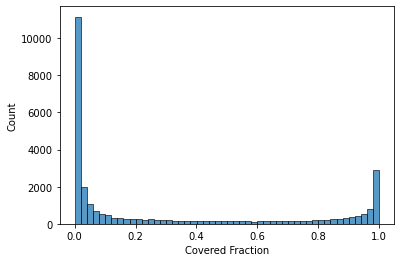

In [21]:
covtable = pd.read_csv(rootdir + "/tables/genome_coverage_info.95.csv", sep="\t")

sns.histplot(x="Covered Fraction", data=covtable, bins=50)
plt.show()

In [22]:
covtable = covtable[covtable["Covered Fraction"]>=0.50]
covtable["clean_sample"] = covtable["Sample"].apply(lambda x: \
    site_dict[x.split("_")[1].split("m")[0].replace("R", "A")] + "_" + x.split("_")[1].split("m")[1] + "m")
covtotals = covtable.groupby("clean_sample", as_index=False).aggregate({"Mean": "sum"}).rename(columns={"Mean": "total_coverage"})
covtable = covtable.merge(covtotals, how="left")
covtable["relative_coverage"] = covtable.apply(lambda x: x["Mean"]/x["total_coverage"], axis=1)
covtable["perc_relative_coverage"] = covtable["relative_coverage"].apply(lambda x: x*100)
covtable["log_relative_coverage"] = covtable["relative_coverage"].apply(lambda x: math.log10(x) if x != 0 else 0)
covtable.head()

,Sample,Genome,Read Count,Mean,Covered Fraction,Length,clean_sample,total_coverage,relative_coverage,perc_relative_coverage,log_relative_coverage
0,genomes_R3000m1000m.sorted,OC4_1000m_MAG_2,159242,5.912105,0.954002,3905352,OC3_1000m,9718.908003,0.000608,0.060831,-3.215875
1,genomes_R3000m1000m.sorted,OC6_2000m_MAG_74,946559,54.625896,0.996455,2499610,OC3_1000m,9718.908003,0.005621,0.562058,-2.250219
2,genomes_R3000m1000m.sorted,OC2_50m_MAG_103,60321,4.949289,0.664882,1793480,OC3_1000m,9718.908003,0.000509,0.050924,-3.293075
3,genomes_R3000m1000m.sorted,OC4_3000m_MAG_162,473177,11.888220,0.934526,5728306,OC3_1000m,9718.908003,0.001223,0.122321,-2.912501
4,genomes_R3000m1000m.sorted,OC4_3000m_MAG_8,20895,1.244621,0.552117,2394404,OC3_1000m,9718.908003,0.000128,0.012806,-3.892580


In [23]:
covpiv = covtable.pivot(index="Genome", columns="clean_sample", values="perc_relative_coverage").fillna(0).reset_index()
base = base.merge(covpiv, how="left", left_on="user_genome", right_on="Genome")

## aai

In [20]:
cmdir("/oak/stanford/groups/dekas/db/gtdb/release226/genomic_reps")
cmdir(rootdir + "genomes/aai_gtdb/")
from Bio.SeqIO.QualityIO import FastqGeneralIterator as fqi

### format gtdb

In [ ]:
# set up the database
for g in glob.glob("/oak/stanford/groups/dekas/db/gtdb/release226/skani/database/GCF/*/*/*/*"):
    name = os.path.basename(g).replace(".gz", "")
    print(name)
    break
    with open("/oak/stanford/groups/dekas/db/gtdb/release226/genomic_reps_refseq/" + name, "w") as out:
        with gzip.open(g, "rt") as handle:
            for record in sfp(handle):
                out.write(">%s\n%s\n" %(record[0], record[1]))

In [21]:
# write to multiple wrappers
refs = glob.glob("/oak/stanford/groups/dekas/db/gtdb/release226/genomic_reps/*")
wrapper = open(rootdir + "genomes/aai_gtdb/wrapper.sh", "w")

n = math.ceil(len(refs)/20)
for i in range(0, len(refs),n):
    chunk = str(int(i/n)+1)
    cmdir(rootdir + "genomes/aai_gtdb/chunk" + chunk)
    wrapper.write("cp %s %s\n" %(" ".join(refs[i:i + n]), rootdir + "genomes/aai_gtdb/chunk" + chunk))

wrapper.close()

### process queries

In [28]:
cmdir(rootdir + "genomes/aai_gtdb/query")
# reformat query genomes and build db
for genome in glob.glob(rootdir + "genomes/drep/dereplicated_genomes/*"):
    name = os.path.basename(genome)
    with open(rootdir + "genomes/aai_gtdb/query/" + name, "w") as out:
        for record in sfp(open(genome)):
            out.write(">%s\n%s\n" %(record[0], record[1]))
            
cmd = "fastaai build_db --genomes %s --threads 20 --verbose \
        --output %s --database %s --compress" %(rootdir + "genomes/aai_gtdb/query",
                                                rootdir + "genomes/aai_gtdb/query/", "query.db")
print(cmd)            

fastaai build_db --genomes /scratch/users/ajaffe/ocdata/genomes/aai_gtdb/query --threads 20 --verbose         --output /scratch/users/ajaffe/ocdata/genomes/aai_gtdb/query/ --database query.db --compress


### run

In [29]:
# use python 3.9
with open(rootdir + "genomes/aai_gtdb/runfaai.sh", "w") as out:
    
    for chunk in glob.glob(rootdir + "genomes/aai_gtdb/chunk*"):
        build = "fastaai build_db --genomes %s --threads 20 --verbose \
                --output %s --database %s --compress" %(chunk, chunk + "/fastAAI", "rep.db")
        run = "fastaai db_query --query %s --target %s --threads 20 \
                --verbose --output %s" %(rootdir + "genomes/aai_gtdb/query/database/query.db", chunk + "/fastAAI/database/rep.db",
                                         chunk + "/results")
        out.write(sbatch("chunk", 20, " && ".join([build,run])) + "\n")

### read in results

In [15]:
def clean_perc(value):
    
    if "%" in value:
        return float(re.search("[<>]([0-9]+)%", value).group(1))
    else: return float(value)

In [16]:
all_results = []

for table in glob.glob(rootdir + "genomes/aai_gtdb/chunk*/results/results/*txt"):
    
    table = pd.read_csv(table, sep="\t", dtype="string").dropna(subset=["AAI_estimate"])
    table["aai_clean"] = table["AAI_estimate"].apply(clean_perc)
    # first derep within chunk to cut down on memory use
    table = table.sort_values("aai_clean", ascending=False).drop_duplicates("query")
    all_results.append(table)

# then dereplicate across chunks
all_results_df = pd.concat(all_results).sort_values("aai_clean", ascending=False).drop_duplicates("query")
all_results_df.to_csv(rootdir + "tables/gtdb_aai_info.tsv", sep="\t", index=False)
all_results_df.head()

,query,target,avg_jacc_sim,jacc_SD,num_shared_SCPs,poss_shared_SCPs,AAI_estimate,aai_clean
1232,OC3_1000m_MAG_212.fa,GCF_029269135.1_genomic.fna,0.888,<NA>,62,63,>90%,90.0
1595,OC3_3000m_MAG_45.fa,GCF_900111895.1_genomic.fna,0.8957,<NA>,54,54,>90%,90.0
858,OC6_2000m_MAG_135.fa,GCF_014596295.1_genomic.fna,0.907,<NA>,49,49,>90%,90.0
1415,OC3_500m_MAG_29.fa,GCF_037152175.1_genomic.fna,0.9467,<NA>,68,68,>90%,90.0
429,OC3_3000m_MAG_39.fa,GCF_003097235.1_genomic.fna,0.8594,<NA>,74,74,>90%,90.0


/tmp/ipykernel_13811/3326744562.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["lowest_level"] = test["classification"].apply(get_lowest_level)
/tmp/ipykernel_13811/3326744562.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["query"] = test["user_genome"].apply(lambda x: x + ".fa")


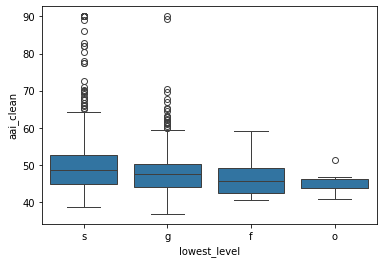

In [18]:
def get_lowest_level(value):
    
    splt = value.split(";")
    lowest = "s"
    
    for i, s in enumerate(splt):
        r = s[1:]
        if r == "__":
            lowest = splt[i-1][0]
            break
     
    return lowest

test = gtresults[["user_genome", "classification"]]
test["lowest_level"] = test["classification"].apply(get_lowest_level)
test["query"] = test["user_genome"].apply(lambda x: x + ".fa")
test = test.merge(all_results_df[["query", "aai_clean"]], how="left", on="query")

sns.boxplot(x="lowest_level", y="aai_clean", 
            data=test, order=["s", "g", "f", "o"])
plt.show()

In [24]:
aai_results = pd.read_csv(rootdir + "tables/gtdb_aai_info.tsv", sep="\t")
aai_results["user_genome"] = aai_results["query"].apply(lambda x: x.replace(".fa", ""))
base = base.merge(aai_results[["user_genome", "aai_clean"]], how="left")
base.head()

,user_genome,classification,bin_name,original_name,refined_nscafs,refined_binlen,checkm_completeness,checkm_redundancy,refined_gunc_css,refined_gunc_contam,...,OC5_500m,OC5_50m,OC6_1000m,OC6_150m,OC6_2000m,OC6_3000m,OC6_4000m,OC6_500m,OC6_50m,aai_clean
0,OC2_150m_MAG_100,d__Archaea;p__Thermoplasmatota;c__Poseidoniia;...,OC2_150m_MAG_100,A500m150m.100,155,876146,52.89,0.18,0.00,0.00,...,1.599083,0.0,0.234011,0.239761,0.0,0.0,0.0,1.898998,0.0,81.74
1,OC2_150m_MAG_124,d__Archaea;p__Thermoplasmatota;c__Poseidoniia;...,OC2_150m_MAG_124,A500m150m.124,105,1289673,70.48,0.48,0.07,0.03,...,0.386328,0.0,0.242656,0.024227,0.0,0.0,0.0,0.395981,0.0,82.98
2,OC2_150m_MAG_185,d__Archaea;p__Thermoplasmatota;c__Poseidoniia;...,OC2_150m_MAG_185,A500m150m.185,351,1241371,65.28,2.80,0.26,0.04,...,0.040762,0.0,0.000000,0.000000,0.0,0.0,0.0,0.065028,0.0,78.35
3,OC2_150m_MAG_207,d__Archaea;p__Thermoplasmatota;c__Poseidoniia;...,OC2_150m_MAG_207,A500m150m.207,334,1086583,59.03,0.00,0.00,0.00,...,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,79.32
4,OC2_500m_MAG_107,d__Archaea;p__Thermoproteota;c__Nitrososphaeri...,OC2_500m_MAG_107,A500m500m.107,171,798507,77.45,3.23,0.00,0.00,...,0.139256,0.0,0.000000,1.862461,0.0,0.0,0.0,0.084545,0.0,90.00


## plots

In [138]:
cmdir(rootdir + "figures")

### heatmap

In [25]:
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib.colors import LogNorm

In [26]:
# cluster genomes based on log rel cov
covpiv = covtable.pivot(index="clean_sample", columns="Genome", values="log_relative_coverage").fillna(0)
col_clustering = linkage(covpiv.transpose(), method='average', metric="euclidean")
col_idx = dendrogram(col_clustering, no_plot=True)["ivl"]
cols = [covpiv.columns[int(i)] for i in col_idx]

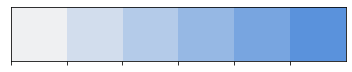

In [27]:
new_pal = sns.light_palette((250, 70, 60), input="husl")
sns.palplot(new_pal)
plt.show()

In [49]:
colcolors = []

for i, column in enumerate(cols):
    
    if column in ["OC2_150m_MAG_124", "OC6_4000m_MAG_91"]:
        
        colcolors.append("red")
        print(i)
    
    else: colcolors.append("lightgrey")

print(colcolors.count("red"))

423
909
2


In [31]:
samples_sorted = sorted([item for item in base.columns if "OC" in item], 
                        key = lambda x: (int(x.split("_")[1].replace("m","")), x.split("_")[0], ))
samples_sorted_dict = {item:i for i, item in enumerate(samples_sorted)}

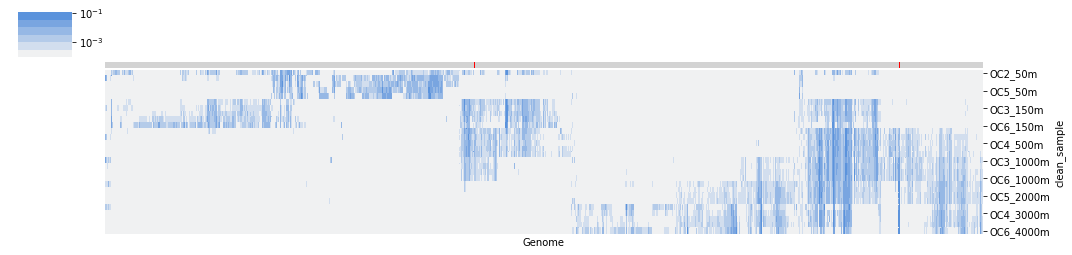

In [34]:
# prep matrix
relpiv = covtable.pivot(index="clean_sample", columns="Genome", values="relative_coverage").reset_index().fillna(covtable["relative_coverage"].min()*1.01)
relpiv_sorted = relpiv.sort_values(by="clean_sample", key=lambda col: [samples_sorted_dict[x] for x in col])
relpiv_sorted.index = relpiv_sorted["clean_sample"]
relpiv_sorted = relpiv_sorted.drop("clean_sample", axis=1)
relpiv_sorted = relpiv_sorted[cols]

# plot
sns.clustermap(relpiv_sorted,cmap=new_pal,norm=LogNorm(covtable["relative_coverage"].min(), covtable["relative_coverage"].max()), 
    row_cluster=False,col_cluster=False, col_colors=colcolors, xticklabels=False, figsize=(15,3.5), dendrogram_ratio=(0.1,0.2))
plt.savefig(rootdir + "figures/heatmap_all.svg", format="svg")
plt.show()

### divergence: depth

In [35]:
def get_lowest_level(value):
    
    splt = value.split(";")
    lowest = "s"
    
    for i, s in enumerate(splt):
        r = s[1:]
        if r == "__":
            lowest = splt[i-1][0]
            break
     
    return lowest

In [36]:
base["lowest_level"] = base["classification"].apply(get_lowest_level)

In [37]:
divergence_info = defaultdict(list)

for site in ["OC2", "OC3", "OC4", "OC5", "OC6"]:
    
    for depth in ["50m", "150m", "500m", "1000m", "2000m", "3000m", "4000m"]:
        
        if site + "_" + depth in base.columns:
            
            aais = []
            levels = []
            weights = []
            products = []
            
            for key, row in base.iterrows():
                if row[site + "_" + depth] != 0:
                    aais.append(row["aai_clean"])
                    levels.append(row["lowest_level"])
                    weights.append(row[site + "_" + depth])
                    products.append(row[site + "_" + depth]*row["aai_clean"])
                    
            divergence_info["site"].append(site)
            divergence_info["depth"].append(-1*int(depth.replace("m","")))
            divergence_info["mean_aai"].append(np.mean(aais))
            divergence_info["weighted_aai"].append(sum(products)/sum(weights))
            
            for level in base["lowest_level"].unique():
                divergence_info[level].append(levels.count(level)/len(levels)*100)
            
divergence_df = pd.DataFrame(divergence_info)
divergence_df.head()

,site,depth,mean_aai,weighted_aai,g,s,o,f
0,OC2,-50,81.724599,85.976732,39.465875,58.160237,0.296736,2.077151
1,OC2,-150,78.275678,82.491657,45.741325,49.842271,0.315457,4.100946
2,OC2,-500,80.402320,79.816239,35.200000,61.200000,0.000000,3.600000
3,OC3,-50,83.166333,85.665755,36.666667,62.380952,0.000000,0.952381
4,OC3,-150,79.075014,83.693301,44.927536,51.884058,0.289855,2.898551


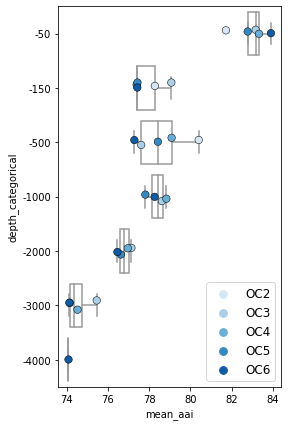

In [39]:
divergence_df["depth_categorical"] = divergence_df["depth"].apply(lambda x: str(x))

plt.figure(figsize=[4,7])
sns.boxplot(
    x="mean_aai", y="depth_categorical", color="white",
    data=divergence_df, fliersize=0
)
kws = dict(linewidth=.5, edgecolor="black")
sns.stripplot(
    x="mean_aai", y="depth_categorical", hue="site", size=7.5,
    data=divergence_df, palette="Blues", zorder=10, **kws
)

plt.legend(bbox_to_anchor=(1, 0), loc='lower right', fontsize=12)
plt.savefig(rootdir + "figures/unweighted_gtdb_aai_depth.svg", format="svg", facecolor="white")
plt.show()

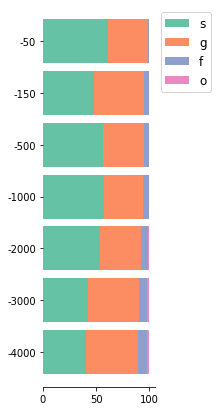

In [43]:
dgb = divergence_df.groupby("depth", as_index=False).aggregate({"g":"mean", 
        "s": "mean", "o":"mean", "f":"mean"})
row_order = sorted(dgb["depth"].unique(), reverse=False)
dgb.index = dgb.depth
dgb = dgb.drop("depth", axis=1)
form_order = ["s", "g", "f", "o",]
palette = sns.color_palette("Set2")
dgb[form_order].loc[row_order,].plot.barh(color=[palette[i] for i, form in enumerate(form_order)], width=0.85,stacked=True, 
    linewidth=0.3, figsize=(2,7), legend=None)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=12)
plt.ylabel("")
sns.despine(bottom=False, left=True)
plt.savefig(rootdir + "figures/lowest_level.svg", format="svg", facecolor="white")
plt.show()

### divergence: rank

In [44]:
from scipy import stats

In [45]:
# rank based on avg rel cov

def compute_mean(row):
    
    buffer = []
    
    for col in base.columns:
        if ("OC" in col) and (row[col] != 0):
            buffer.append(row[col])
    
    return np.mean(buffer)

base["avg_abund"] = base.apply(lambda x: compute_mean(x), axis=1)
base_sorted = base.sort_values("avg_abund", ascending=False).reset_index()
base_sorted["rank"] = base_sorted.index
base_sorted.head()

,index,user_genome,classification,bin_name,original_name,refined_nscafs,refined_binlen,checkm_completeness,checkm_redundancy,refined_gunc_css,...,OC6_150m,OC6_2000m,OC6_3000m,OC6_4000m,OC6_500m,OC6_50m,aai_clean,lowest_level,avg_abund,rank
0,497,OC4_2000m_MAG_102,d__Bacteria;p__SAR324;c__SAR324;o__SAR324;f__N...,OC4_2000m_MAG_102,A3500m2000m.102,565,2663446,85.54,0.26,0.00,...,3.923099,7.546549,6.120181,2.251164,7.448244,0.000000,90.0,s,5.457892,0
1,940,OC6_4000m_MAG_91,d__Bacteria;p__Actinomycetota;c__Acidimicrobii...,OC6_4000m_MAG_91,A4500m4000m.91,198,2449237,95.73,5.70,0.20,...,0.000000,6.113232,6.712470,8.742671,0.397742,0.000000,90.0,s,4.453526,1
2,51,OC4_1000m_MAG_200,d__Archaea;p__Thermoplasmatota;c__Poseidoniia;...,OC4_1000m_MAG_200,A3500m1000m.200,179,1114444,66.09,1.66,0.24,...,0.000000,8.224372,2.597899,0.000000,3.519060,0.000000,90.0,s,3.866817,2
3,978,OC6_50m_MAG_139,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,OC6_50m_MAG_139,A4500m50m.139,172,1112414,55.29,4.06,0.00,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.951285,90.0,s,3.473432,3
4,76,OC5_1000m_MAG_126,d__Archaea;p__Thermoproteota;c__Nitrososphaeri...,OC5_1000m_MAG_126,A4000m1000m.126,193,655072,52.04,5.83,0.00,...,0.099136,2.438292,1.088937,0.285743,5.592540,0.000000,60.5,g,2.936486,4


In [46]:
def compute_percentile(row):
    
    distribution = list(base_sorted[(base_sorted["user_genome"]!=row["user_genome"])]["avg_abund"])
    percentile = stats.percentileofscore(distribution, row["avg_abund"], kind="rank")
    return percentile

base_sorted["percentile_abund"] = base_sorted.apply(lambda x: compute_percentile(x), axis=1)
base_sorted.head()

,index,user_genome,classification,bin_name,original_name,refined_nscafs,refined_binlen,checkm_completeness,checkm_redundancy,refined_gunc_css,...,OC6_2000m,OC6_3000m,OC6_4000m,OC6_500m,OC6_50m,aai_clean,lowest_level,avg_abund,rank,percentile_abund
0,497,OC4_2000m_MAG_102,d__Bacteria;p__SAR324;c__SAR324;o__SAR324;f__N...,OC4_2000m_MAG_102,A3500m2000m.102,565,2663446,85.54,0.26,0.00,...,7.546549,6.120181,2.251164,7.448244,0.000000,90.0,s,5.457892,0,100.000000
1,940,OC6_4000m_MAG_91,d__Bacteria;p__Actinomycetota;c__Acidimicrobii...,OC6_4000m_MAG_91,A4500m4000m.91,198,2449237,95.73,5.70,0.20,...,6.113232,6.712470,8.742671,0.397742,0.000000,90.0,s,4.453526,1,99.900299
2,51,OC4_1000m_MAG_200,d__Archaea;p__Thermoplasmatota;c__Poseidoniia;...,OC4_1000m_MAG_200,A3500m1000m.200,179,1114444,66.09,1.66,0.24,...,8.224372,2.597899,0.000000,3.519060,0.000000,90.0,s,3.866817,2,99.800598
3,978,OC6_50m_MAG_139,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,OC6_50m_MAG_139,A4500m50m.139,172,1112414,55.29,4.06,0.00,...,0.000000,0.000000,0.000000,0.000000,1.951285,90.0,s,3.473432,3,99.700897
4,76,OC5_1000m_MAG_126,d__Archaea;p__Thermoproteota;c__Nitrososphaeri...,OC5_1000m_MAG_126,A4000m1000m.126,193,655072,52.04,5.83,0.00,...,2.438292,1.088937,0.285743,5.592540,0.000000,60.5,g,2.936486,4,99.601196


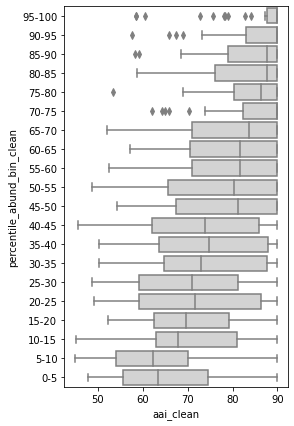

In [47]:
base_sorted["percentile_abund_bin"] = pd.cut(base_sorted["percentile_abund"], 20, labels=None)
base_sorted["percentile_abund_bin_clean"] = base_sorted["percentile_abund_bin"].apply(lambda x: str(int(max(float(str(x).split(", ")[0].replace("(", "")), 0))) + \
                                                                                      "-" + str(int(float(str(x).split(", ")[1].replace("]", "")))))
plt.figure(figsize=[4,7])
ax = sns.boxplot(
    y="percentile_abund_bin_clean", x="aai_clean",
    data=base_sorted, orient="h", fliersize=5,
    color="lightgrey"
)
ax.invert_yaxis()
plt.savefig(rootdir + "figures/aai_rank.svg", format="svg")
plt.show()

### spatial distribution

OC2_150m_MAG_124


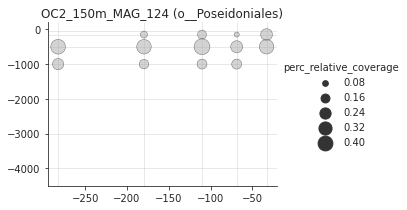

OC6_4000m_MAG_91


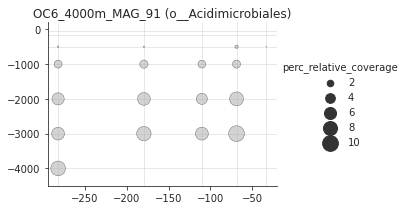

In [50]:
distance_dict = {"500m": -33.15, "3000m": -68.84,
                 "3500m": -110.29, "4000m": -179.65, "4500m": -282.24}

covtable["distance"] = covtable["Sample"].apply(lambda x: distance_dict[x.split("_")[1].split("m")[0].replace("R","") + "m"])
covtable["depth"] = covtable["clean_sample"].apply(lambda x: -1*int(x.split("_")[1].replace("m", "")))

for index in [423, 909]:

    organism = cols[index]
    table = covtable[covtable["Genome"]==organism]
    
    sns.set_style("ticks")
    kws = dict(linewidth=.5, edgecolor="black")
    g = sns.relplot(x="distance", y="depth", color="darkgrey",
        data=table.sort_values(["distance"], ascending=False),
        palette="Set2", size="perc_relative_coverage", 
        sizes=(0,250),height=3, aspect=1.5,alpha=0.50, **kws, legend="brief")
    plt.xlabel("")
    plt.ylabel("")
    plt.ylim([-4500,200])

    for i,ax in enumerate(g.axes.flat):

        for k in covtable["depth"].unique():
            ax.axhline(k, ls="-", zorder=0, linewidth=0.5,color="lightgrey")
        for k in covtable["distance"].unique():
            ax.axvline(k, ls="-", zorder=0, linewidth=0.5,color="lightgrey")
    
    taxonomy = gtresults[gtresults["user_genome"]==organism]["classification"].iloc[0].split(";")[3]
    plt.title(organism + " (" + taxonomy + ")")
    print(organism)
    plt.savefig(rootdir + "figures/%s.svg" %(organism), format="svg", facecolor="white")
    plt.show()
    

## export

In [51]:
samples_sorted = sorted([item for item in base.columns if "OC" in item], 
                        key = lambda x: (x.split("_")[0], int(x.split("_")[1].replace("m",""))))
final_cols = ["user_genome", "original_name", "secondary_cluster", "classification", "aai_clean",
              "refined_nscafs", "refined_binlen", "checkm_completeness", "checkm_redundancy",
              "refined_gunc_css", "refined_gunc_contam", "5S_rRNA", "16S_rRNA", "23S_rRNA", 
              "num_tRNA", "mimag_classification"] + samples_sorted
base[final_cols].to_csv(rootdir + "tables/ocdata_table_s1.tsv", sep="\t", index=False)